# =============== Midprice: ===============

In [132]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import ScalarFormatter
from statsmodels.tsa.stattools import adfuller
from scipy.stats import skew, kurtosis
from statsmodels.tsa.stattools import adfuller
import datetime
import pprint
import statsmodels.tsa.stattools as ts

In [133]:
price_files = [
    "/Users/jameszhao/IMC3/Pre-Comp/Data1/prices_round_1_day_-2.csv",
    "/Users/jameszhao/IMC3/Pre-Comp/Data1/prices_round_1_day_-1.csv",
    "/Users/jameszhao/IMC3/Pre-Comp/Data1/prices_round_1_day_0.csv"
]

# Read and concatenate all price files
price_dfs = [pd.read_csv(f, sep=',') for f in price_files]
all_prices_df = pd.concat(price_dfs, ignore_index=True)

# Save to a new combined CSV
combined_price_path = "/Users/jameszhao/IMC3/Pre-Comp/Data1/prices_combined_days_-2_to_0.csv"
df = pd.read_csv(combined_price_path, sep=',')

In [134]:
products = ['RAINFOREST_RESIN', 'KELP', 'SQUID_INK']

In [135]:
# Pivot to get KELP and SQUID_INK mid_prices in columns
pivot_df = df.pivot_table(index='timestamp', columns='product', values='mid_price')


In [136]:
# Drop NaNs (only keep timestamps where both KELP and SQUID_INK exist)
pivot_df = pivot_df[['KELP', 'SQUID_INK']].dropna()

In [137]:
pivot_df.head()

product,KELP,SQUID_INK
timestamp,,
0,2019.500000,1991.666667
100,2019.500000,1991.833333
200,2019.166667,1990.166667
300,2019.166667,1989.833333
400,2018.833333,1990.166667


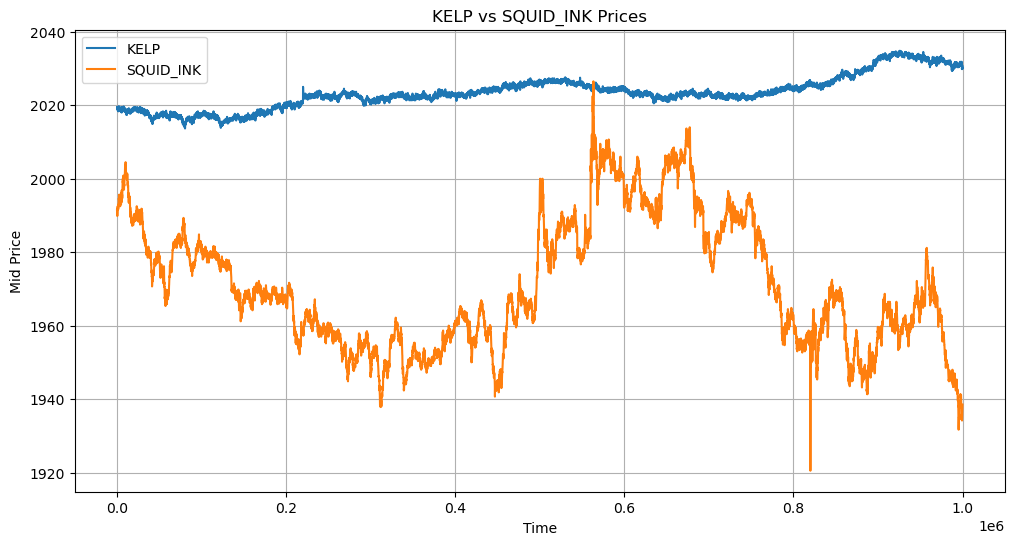

In [138]:
# Plot the time series
plt.figure(figsize=(12, 6))
plt.plot(pivot_df.index, pivot_df['KELP'], label='KELP')
plt.plot(pivot_df.index, pivot_df['SQUID_INK'], label='SQUID_INK')
plt.xlabel("Time")
plt.ylabel("Mid Price")
plt.title("KELP vs SQUID_INK Prices")
plt.legend()
plt.grid(True)
plt.show()

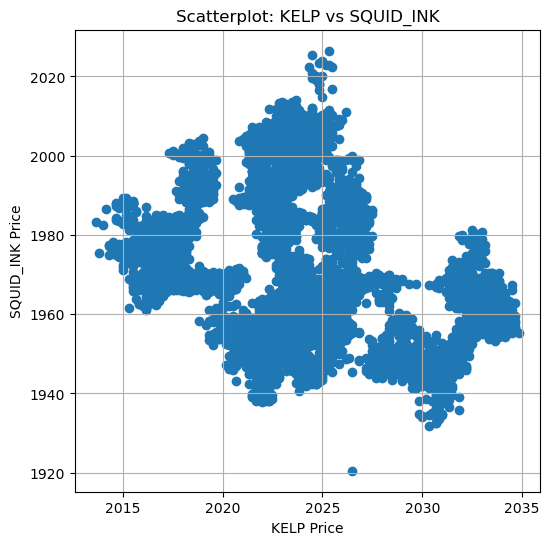

In [139]:
# Scatterplot
plt.figure(figsize=(6, 6))
plt.scatter(pivot_df['KELP'], pivot_df['SQUID_INK'])
plt.xlabel("KELP Price")
plt.ylabel("SQUID_INK Price")
plt.title("Scatterplot: KELP vs SQUID_INK")
plt.grid(True)
plt.show()

In [140]:
# Run linear regression to find hedge ratio (beta)
X = ts.add_constant(pivot_df['KELP'])  # Adds intercept term
model = ts.OLS(pivot_df['SQUID_INK'], X).fit()
beta_hr = model.params['KELP']

In [141]:
# Calculate residuals
pivot_df['residual'] = pivot_df['SQUID_INK'] - beta_hr * pivot_df['KELP']

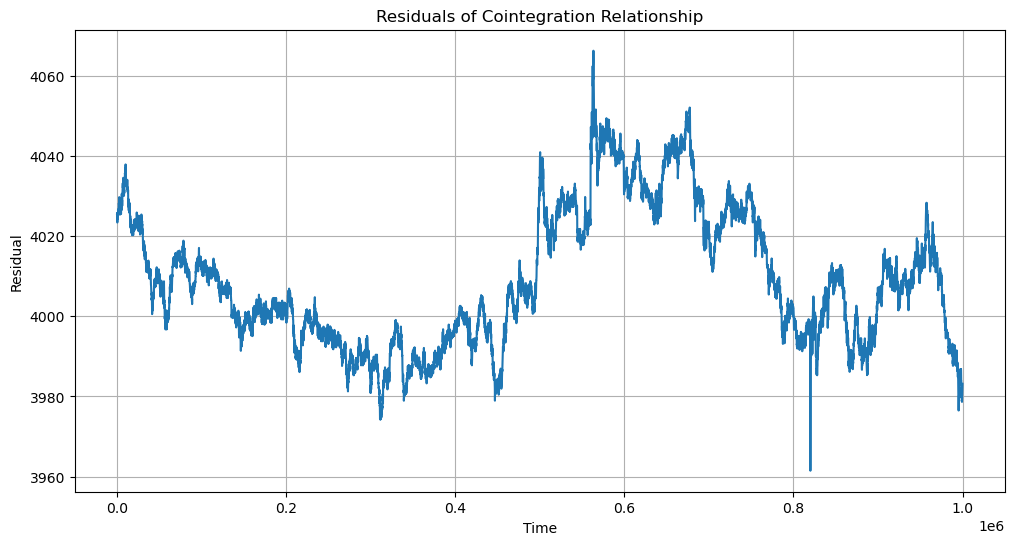

In [142]:
# Plot residuals
plt.figure(figsize=(12, 6))
plt.plot(pivot_df.index, pivot_df['residual'])
plt.title("Residuals of Cointegration Relationship")
plt.xlabel("Time")
plt.ylabel("Residual")
plt.grid(True)
plt.show()

In [143]:
test_statistic, p_value, lags_used, n_obs, critical_values, ic_best = cadf_result

print("----- CADF Test Summary -----")
print(f"Test Statistic     : {test_statistic:.4f}")
print(f"P-Value            : {p_value:.4f}")
print(f"Lags Used          : {lags_used}")
print(f"Number of Observations: {n_obs}")
print("Critical Values    :")
for key, value in critical_values.items():
    print(f"    {key} : {value:.4f}")
print(f"IC Best (AIC)      : {ic_best:.2f}")
print("\nInterpretation:")

# Interpretation logic
if p_value < 0.05 and test_statistic < critical_values['5%']:
    print(" The residuals are likely stationary — the series are COINTEGRATED.")
    print(" Suggests a mean-reverting relationship (potential for stat arb).")
else:
    print(" The residuals are likely non-stationary — no strong cointegration evidence.")
    print(" Consider trying different time periods, transformations, or asset pairs.")

----- CADF Test Summary -----
Test Statistic     : -19.4854
P-Value            : 0.0000
Lags Used          : 23
Number of Observations: 9975
Critical Values    :
    1% : -3.4310
    5% : -2.8618
    10% : -2.5669
IC Best (AIC)      : -123235.63

Interpretation:
 The residuals are likely stationary — the series are COINTEGRATED.
 Suggests a mean-reverting relationship (potential for stat arb).


#  =============== Simple Returns:  ===============

In [144]:
# Compute simple returns (percentage change)
returns_df = pivot_df.pct_change().dropna()

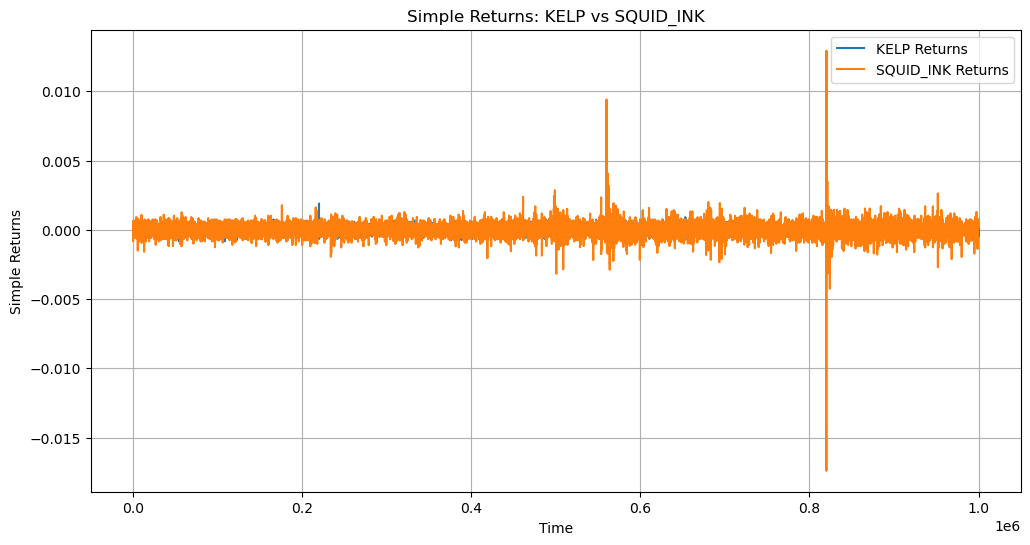

In [145]:
# Plot the return time series
plt.figure(figsize=(12, 6))
plt.plot(returns_df.index, returns_df['KELP'], label='KELP Returns')
plt.plot(returns_df.index, returns_df['SQUID_INK'], label='SQUID_INK Returns')
plt.xlabel("Time")
plt.ylabel("Simple Returns")
plt.title("Simple Returns: KELP vs SQUID_INK")
plt.legend()
plt.grid(True)
plt.show()


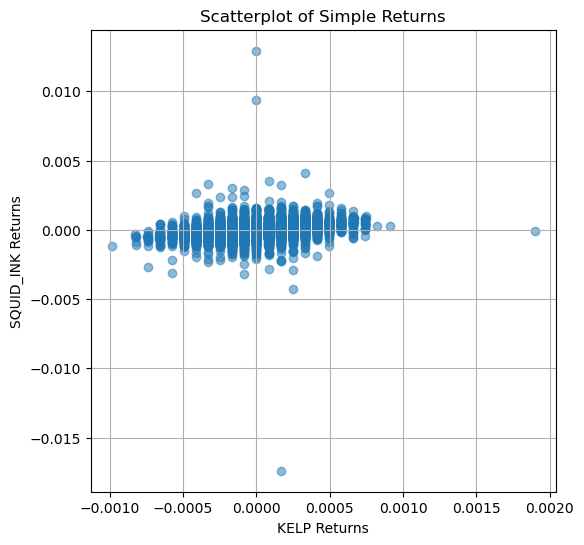

In [146]:
# Scatterplot of returns
plt.figure(figsize=(6, 6))
plt.scatter(returns_df['KELP'], returns_df['SQUID_INK'], alpha=0.5)
plt.xlabel("KELP Returns")
plt.ylabel("SQUID_INK Returns")
plt.title("Scatterplot of Simple Returns")
plt.grid(True)
plt.show()

In [147]:
# Linear regression (OLS) on returns to find hedge ratio
X = ts.add_constant(returns_df['KELP'])
model = ts.OLS(returns_df['SQUID_INK'], X).fit()
beta_hr = model.params['KELP']

# Residuals of the linear relationship
returns_df['residual'] = returns_df['SQUID_INK'] - beta_hr * returns_df['KELP']

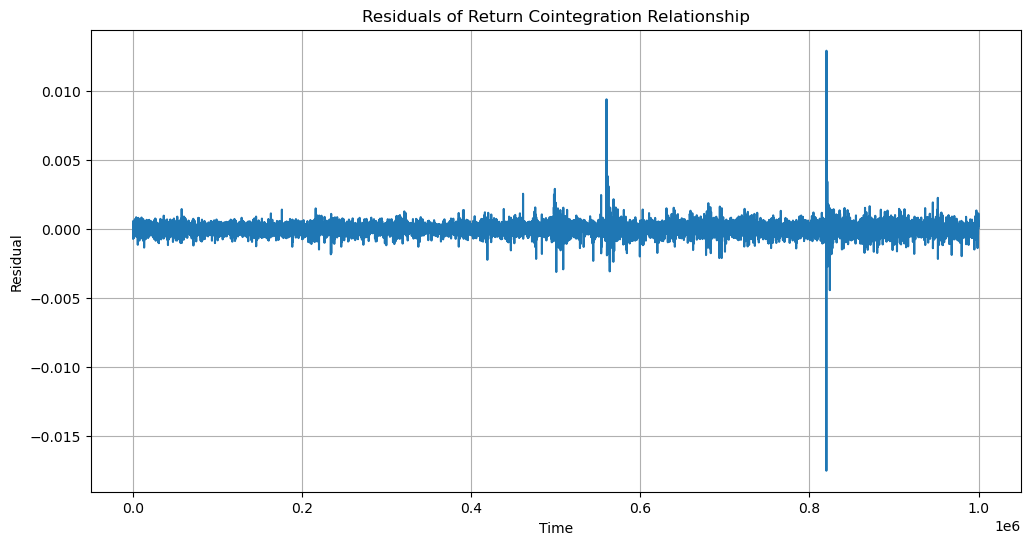

In [148]:
# Plot residuals
plt.figure(figsize=(12, 6))
plt.plot(returns_df.index, returns_df['residual'])
plt.title("Residuals of Return Cointegration Relationship")
plt.xlabel("Time")
plt.ylabel("Residual")
plt.grid(True)
plt.show()

In [149]:
# CADF test on residuals
cadf_result = adfuller(returns_df['residual'])

In [150]:
test_statistic, p_value, lags_used, n_obs, critical_values, ic_best = cadf_result

print("----- CADF Test on Simple Returns -----")
print(f"Test Statistic     : {test_statistic:.4f}")
print(f"P-Value            : {p_value:.4f}")
print(f"Lags Used          : {lags_used}")
print(f"Number of Observations: {n_obs}")
print("Critical Values    :")
for key, value in critical_values.items():
    print(f"    {key} : {value:.4f}")
print(f"IC Best (AIC)      : {ic_best:.2f}")
print("\nInterpretation:")

if p_value < 0.05 and test_statistic < critical_values['5%']:
    print("Residuals are likely stationary — simple returns are cointegrated.")
else:
    print("Residuals are likely non-stationary — no strong cointegration in returns.")

----- CADF Test on Simple Returns -----
Test Statistic     : -19.4830
P-Value            : 0.0000
Lags Used          : 23
Number of Observations: 9975
Critical Values    :
    1% : -3.4310
    5% : -2.8618
    10% : -2.5669
IC Best (AIC)      : -123244.86

Interpretation:
Residuals are likely stationary — simple returns are cointegrated.


#  =============== Log Returns:  ===============

In [151]:
# Compute log returns
log_returns_df = np.log(pivot_df).diff().dropna()

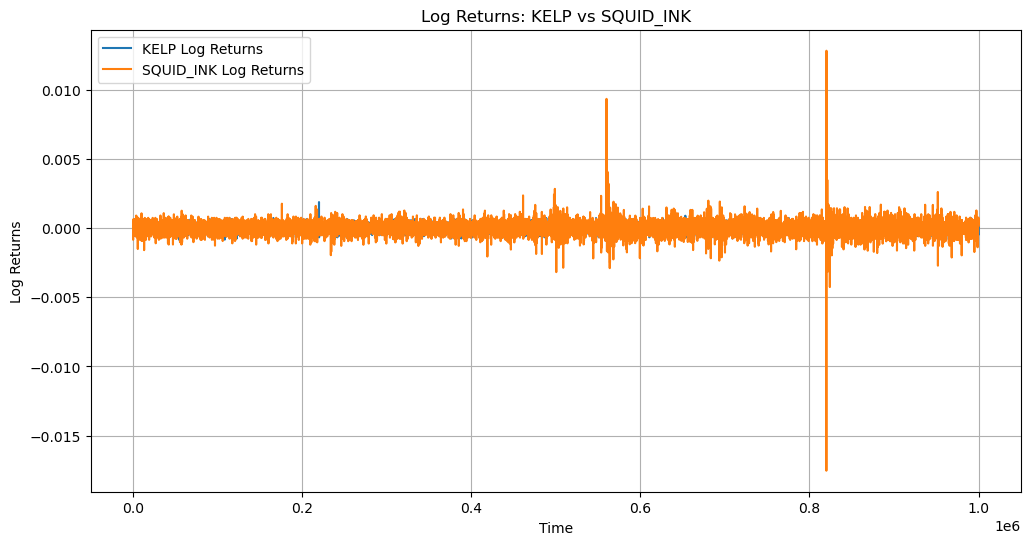

In [152]:
# Plot the return time series
plt.figure(figsize=(12, 6))
plt.plot(log_returns_df.index, log_returns_df['KELP'], label='KELP Log Returns')
plt.plot(log_returns_df.index, log_returns_df['SQUID_INK'], label='SQUID_INK Log Returns')
plt.xlabel("Time")
plt.ylabel("Log Returns")
plt.title("Log Returns: KELP vs SQUID_INK")
plt.legend()
plt.grid(True)
plt.show()

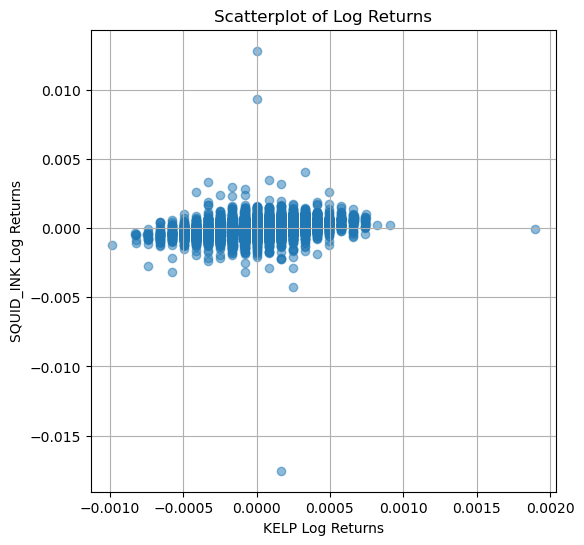

In [153]:
# Scatterplot of log returns
plt.figure(figsize=(6, 6))
plt.scatter(log_returns_df['KELP'], log_returns_df['SQUID_INK'], alpha=0.5)
plt.xlabel("KELP Log Returns")
plt.ylabel("SQUID_INK Log Returns")
plt.title("Scatterplot of Log Returns")
plt.grid(True)
plt.show()

In [154]:
# Linear regression (OLS) on log returns to find hedge ratio
X = ts.add_constant(log_returns_df['KELP'])
model = ts.OLS(log_returns_df['SQUID_INK'], X).fit()
beta_hr = model.params['KELP']

In [155]:
# Residuals of the linear relationship
log_returns_df['residual'] = log_returns_df['SQUID_INK'] - beta_hr * log_returns_df['KELP']

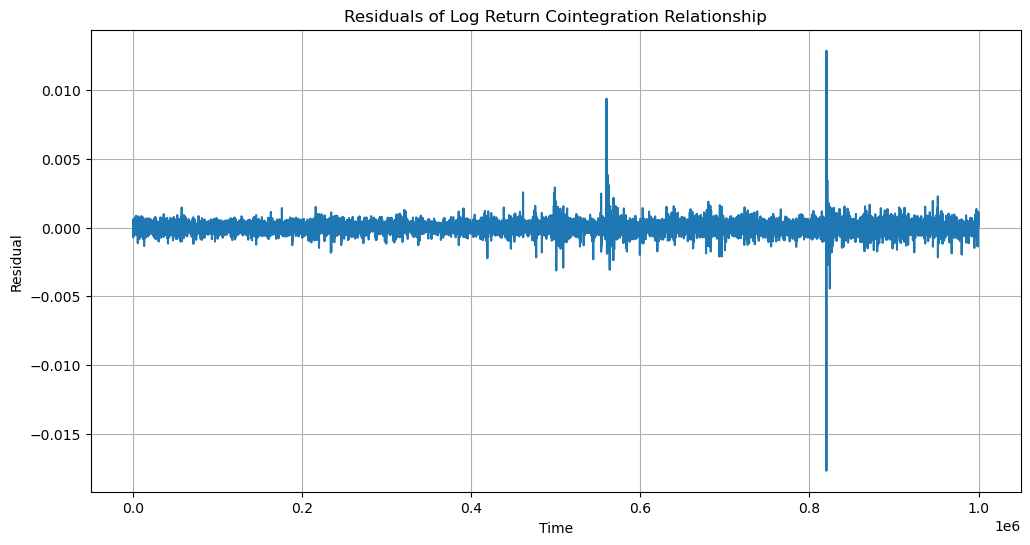

In [156]:
# Plot residuals
plt.figure(figsize=(12, 6))
plt.plot(log_returns_df.index, log_returns_df['residual'])
plt.title("Residuals of Log Return Cointegration Relationship")
plt.xlabel("Time")
plt.ylabel("Residual")
plt.grid(True)
plt.show()

In [157]:
# CADF test on residuals
cadf_result = adfuller(log_returns_df['residual'])

In [158]:
test_statistic, p_value, lags_used, n_obs, critical_values, ic_best = cadf_result

print("----- CADF Test on Log Returns -----")
print(f"Test Statistic     : {test_statistic:.4f}")
print(f"P-Value            : {p_value:.4f}")
print(f"Lags Used          : {lags_used}")
print(f"Number of Observations: {n_obs}")
print("Critical Values    :")
for key, value in critical_values.items():
    print(f"    {key} : {value:.4f}")
print(f"IC Best (AIC)      : {ic_best:.2f}")
print("\nInterpretation:")

if p_value < 0.05 and test_statistic < critical_values['5%']:
    print("Residuals are likely stationary — log returns are cointegrated.")
else:
    print("Residuals are likely non-stationary — no strong cointegration in log returns.")

----- CADF Test on Log Returns -----
Test Statistic     : -19.4854
P-Value            : 0.0000
Lags Used          : 23
Number of Observations: 9975
Critical Values    :
    1% : -3.4310
    5% : -2.8618
    10% : -2.5669
IC Best (AIC)      : -123235.63

Interpretation:
Residuals are likely stationary — log returns are cointegrated.
